In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from utils import print_decorated

Дослідження часової затримки на виконання сортування колекції з 1 000 000 об'єктів, ідентифікація закону розподілу (Нормальний розподіл) та побудова імітаційного генератора

In [2]:
def measure_sorting_durations(runs=50, array_size=1_000_000):
    durations = []
    for _ in range(runs):
        arr = np.random.randint(0, 10**9, size=array_size)
        start_time = time.perf_counter()
        arr.sort()
        end_time = time.perf_counter()
        durations.append(end_time - start_time)
    return np.array(durations)

Підгонка параметрів нормального розподілу (середнє $\mu$ та стандартне відхилення $\sigma$) та перевірка гіпотези за тестом Шапіро-Вілка

In [3]:
def analyze_and_fit_norm(durations):
    mu, std = stats.norm.fit(durations)
    shapiro_stat, shapiro_p = stats.shapiro(durations)
    return mu, std, shapiro_stat, shapiro_p

Імітаційний генератор часових затримок та порівняння їх із реальними даними за допомогою двовибіркового критерію Колмогорова-Смірнова (KS-тест)

In [4]:
def simulate_and_compare(durations, mu, std):
    simulated_durations = np.random.normal(loc=mu, scale=std, size=len(durations))
    ks_stat, ks_p = stats.ks_2samp(durations, simulated_durations)
    return simulated_durations, ks_stat, ks_p

Візуалізація порівняння реальних вимірів часу та імітаційного генератора

In [5]:
def plot_timing_comparison(durations, simulated_durations):
    plt.figure(figsize=(8, 4))
    plt.hist(durations, bins=10, density=True, alpha=0.5, color="blue", label="Реальні виміри")
    plt.hist(simulated_durations, bins=10, density=True, alpha=0.5, color="orange", label="Імітаційний генератор")
    plt.title("Порівняння реальної та змодельованої затримки")
    plt.xlabel("Час виконання (секунди)")
    plt.ylabel("Густина")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Головна функція для виконання третього завдання

 Вимірювання часу сортування (10000000 елементів, 200 запусків) 
Збір експериментальних даних часу...
Збір завершено.

Параметри підігнаного Нормального розподілу:
Середнє (mu) = 0.752329 сек
Стандартне відхилення (std) = 0.041464 сек
Тест Шапіро-Вілка на нормальність: stat = 0.8877, p-value = 0.0000
Порівняння реальних та імітованих даних (KS-тест): p-value = 0.0521


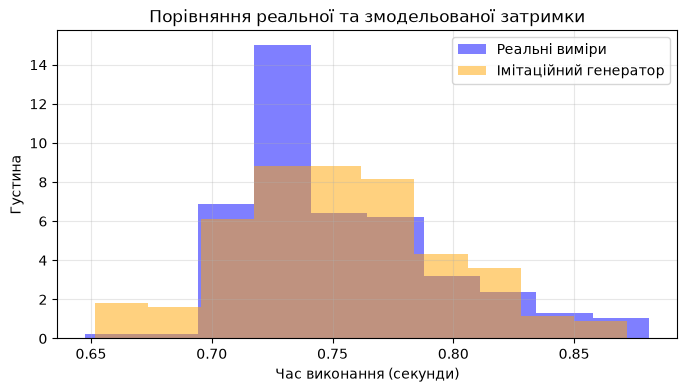

In [11]:
def task_3_timing_simulation(runs=200, array_size=10_000_000):
    print_decorated(f"Вимірювання часу сортування ({array_size} елементів, {runs} запусків)", True)
    
    print("Збір експериментальних даних часу...")
    durations = measure_sorting_durations(runs, array_size)
    print("Збір завершено.")
    
    mu, std, shapiro_stat, shapiro_p = analyze_and_fit_norm(durations)
    
    print(f"\nПараметри підігнаного Нормального розподілу:")
    print(f"Середнє (mu) = {mu:.6f} сек")
    print(f"Стандартне відхилення (std) = {std:.6f} сек")
    print(f"Тест Шапіро-Вілка на нормальність: stat = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
    
    simulated_durations, ks_stat, ks_p = simulate_and_compare(durations, mu, std)
    print(f"Порівняння реальних та імітованих даних (KS-тест): p-value = {ks_p:.4f}")
    
    plot_timing_comparison(durations, simulated_durations)

if __name__ == "__main__":
    task_3_timing_simulation()

Тест Колмагорова-Смірнова дозволяє прийняти гіпотезу про нормальний розподіл